In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nick2908/imdb-movie-reviews-for-sentiment-analysis/finalReviews.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/nick2908/imdb-movie-reviews-for-sentiment-analysis/finalReviews.csv")

In [3]:
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,review,label
0,There isn't too much in the way of suspense or...,1
1,"I cried and laughed and blah, blah, blah. CGI ...",1
2,Not as good as infinity war..,1
3,First review from me. This film deserves it. A...,1
4,This film is an emotional rollercoaster with s...,1


In [4]:
df.shape

(302, 2)

In [5]:
df.head(-2)

,review,label
0,There isn't too much in the way of suspense or...,1
1,"I cried and laughed and blah, blah, blah. CGI ...",1
2,Not as good as infinity war..,1
3,First review from me. This film deserves it. A...,1
4,This film is an emotional rollercoaster with s...,1
...,...,...
295,"💩Just by writing this review, I probably spent...",0
296,"""The Emoji Movie"" is Hollywood's next attempt ...",0
297,Oh boy what do i even say...i knew this movie ...,0
298,"Wow, just from seeing the trailers of this ""th...",0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  302 non-null    object
 1   label   302 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.8+ KB


In [7]:
df.isnull().sum()

review    0
label     0
dtype: int64

In [8]:
df["label"].value_counts()

label
1    170
0    132
Name: count, dtype: int64

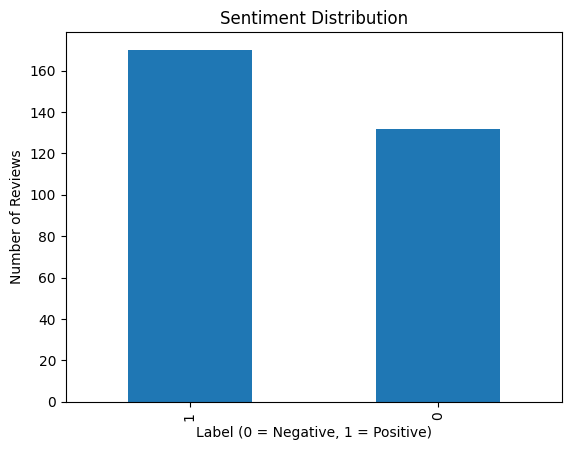

In [9]:
import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()

In [10]:
df["review_length"] = df["review"].apply(len)

print("\nReview Length Statistics:")
print(df["review_length"].describe())


Review Length Statistics:
count     302.000000
mean      452.377483
std       718.248162
min         1.000000
25%        56.250000
50%       188.000000
75%       514.250000
max      5160.000000
Name: review_length, dtype: float64


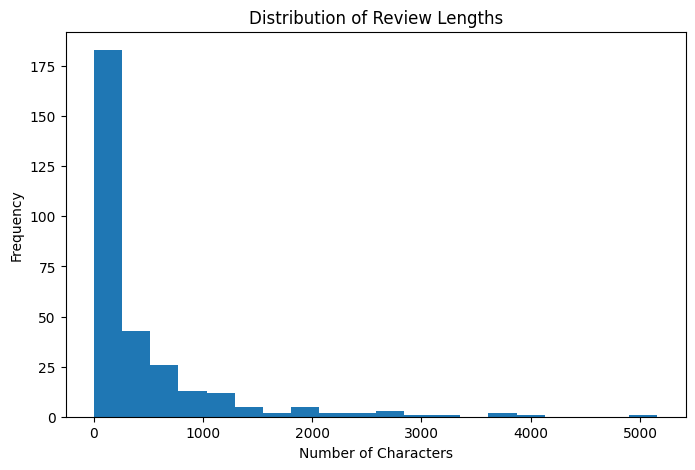

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length"], bins=20)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [12]:
print("\nSample Positive Reviews:")
display(df[df["label"] == 1][["review"]].head(3))


Sample Positive Reviews:


,review
0,There isn't too much in the way of suspense or...
1,"I cried and laughed and blah, blah, blah. CGI ..."
2,Not as good as infinity war..


In [13]:
print("\nSample Negative Reviews:")
display(df[df["label"] == 0][["review"]].head(3))


Sample Negative Reviews:


,review
10,LOOK AT FAT BUMBLING THOR AND LAUGH and ignore...
18,Should have ended on infinity war
24,EndLame is disappointing and messy


## Text Preprocessing

In [14]:
import string
import re

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
df["clean_review"] = df["review"].apply(preprocess_text)

# Compare original and cleaned reviews
comparison = df[["review", "clean_review"]].head(5)
display(comparison)

,review,clean_review
0,There isn't too much in the way of suspense or...,there isnt too much in the way of suspense or ...
1,"I cried and laughed and blah, blah, blah. CGI ...",i cried and laughed and blah blah blah cgi was...
2,Not as good as infinity war..,not as good as infinity war
3,First review from me. This film deserves it. A...,first review from me this film deserves it a s...
4,This film is an emotional rollercoaster with s...,this film is an emotional rollercoaster with s...


## TF-IDF Vectorization

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [17]:
X = tfidf.fit_transform(df["clean_review"])

In [18]:
y = df["label"]

In [19]:
print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (302, 3688)
Labels Shape: (302,)


In [20]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15539 stored elements and shape (302, 3688)>

In [21]:
type(X)

scipy.sparse._csr.csr_matrix

In [22]:
print(X.shape)

(302, 3688)


In [23]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15539 stored elements and shape (302, 3688)>
  Coords	Values
  (0, 3246)	0.21947368956574495
  (0, 1734)	0.09993645612764289
  (0, 3323)	0.08762532780897372
  (0, 2127)	0.07428506962853006
  (0, 1654)	0.10028954605321828
  (0, 3234)	0.28410773073335605
  (0, 3548)	0.07607573479037397
  (0, 2231)	0.17206932210191409
  (0, 3161)	0.142383844215408
  (0, 2266)	0.07546468788234859
  (0, 3156)	0.142383844215408
  (0, 3574)	0.08008785564193649
  (0, 1737)	0.04301733052547852
  (0, 631)	0.09839918427703172
  (0, 3309)	0.08470871783097565
  (0, 3086)	0.15092937576469717
  (0, 452)	0.051989747953557056
  (0, 224)	0.19435165660717274
  (0, 2968)	0.07607573479037397
  (0, 2883)	0.15266531201552083
  (0, 2093)	0.10723127362348936
  (0, 172)	0.16185401650382705
  (0, 1352)	0.08574615568246143
  (0, 1890)	0.11452609111933583
  (0, 3263)	0.11958991567948889
  :	:
  (299, 289)	0.5285412703448132
  (299, 2978)	0.34002355155533087
  (299, 1582

In [24]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (241, 3688)
Testing Features : (61, 3688)
Training Labels  : (241,)
Testing Labels   : (61,)


## Build the Neural Network

In [26]:
"""TF-IDF Vector (3688 Features)
            │
            ▼
Input Layer
            │
            ▼
Dense Layer (128 Neurons)
ReLU
            │
            ▼
Dense Layer (2 Neurons)
Softmax
"""

'TF-IDF Vector (3688 Features)\n            │\n            ▼\nInput Layer\n            │\n            ▼\nDense Layer (128 Neurons)\nReLU\n            │\n            ▼\nDense Layer (2 Neurons)\nSoftmax\n'

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [28]:
# Build the Neural Network
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(2, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-15 17:52:56.914678: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [29]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       472,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 472,450 (1.80 MB)

 Trainable params: 472,450 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [31]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6042 - loss: 0.6885 - val_accuracy: 0.7551 - val_loss: 0.6775
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8906 - loss: 0.6471 - val_accuracy: 0.7551 - val_loss: 0.6616
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9271 - loss: 0.6019 - val_accuracy: 0.7347 - val_loss: 0.6396
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9479 - loss: 0.5453 - val_accuracy: 0.7959 - val_loss: 0.6142
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9583 - loss: 0.4823 - val_accuracy: 0.8163 - val_loss: 0.5873
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9688 - loss: 0.4169 - val_accuracy: 0.7959 - val_loss: 0.5603
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9688 - loss: 0.3526 - val_accuracy: 0.7959 - val_loss: 0.5361
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9792 - loss: 0.2950 - val_accuracy: 0.8163 - val_loss: 0.5151


## Model Evaluation

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [33]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred = y_pred_prob.argmax(axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [34]:
# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 0.7868852459016393
Precision: 0.8108108108108109
Recall   : 0.8333333333333334
F1-Score : 0.821917808219178


In [35]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73        25
           1       0.81      0.83      0.82        36

    accuracy                           0.79        61
   macro avg       0.78      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



## Prediction

In [36]:
# New review
new_review = "This movie was amazing! Such a lovely time."

# Step 1: Preprocess the review
clean_review = preprocess_text(new_review)

# Step 2: Convert to TF-IDF using the EXISTING vectorizer
review_vector = tfidf.transform([clean_review])

# Step 3: Predict probabilities
prediction = model.predict(review_vector, verbose=0)

# Step 4: Get predicted class
predicted_class = prediction.argmax(axis=1)[0]

In [37]:
# Step 5: Display result
labels = {0: "Negative", 1: "Positive"}

print("Original Review:")
print(new_review)

print("\nCleaned Review:")
print(clean_review)

Original Review:
This movie was amazing! Such a lovely time.

Cleaned Review:
this movie was amazing such a lovely time


In [38]:
print(f"Negative: {prediction[0][0]:.4f}")
print(f"Positive: {prediction[0][1]:.4f}")

print("\nPredicted Sentiment:")
print(labels[predicted_class])

Negative: 0.3838
Positive: 0.6162

Predicted Sentiment:
Positive
